In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Görüntü Sıkıştırma

Bu meydan okumada veri olarak **görüntüler** 🖼️ kullanacağız.

Bir görüntüdeki renkleri sadece en sık kullanılan renklerle sınırlayarak görüntü sıkıştırması için **K-means** kullanacaksınız.

## 1) Python ile Görüntüler

Bu bölüm size Python'da görüntülerle nasıl çalıştığımız konusunda biraz anlayış kazandırmalı.

**1. bölüm için kodlama gerekmez, dikkatlice okuyun ve verilen örnekleri çalıştırın.**

### 1.1) Siyah beyaz görüntüler

Bir görüntü, her elemanın bir piksel olduğu bir matris olarak tanımlanabilir.

Renk ölçeği 0 (siyah) ile 255 (beyaz) arasındadır.

Bu nedenle, matristeki her eleman 0 ile 255 arasında bir değere sahip olacaktır.

<img src="https://miro.medium.com/max/1386/1*bV7S0zACdidh11ikjYpLpQ.png">

`matris` dedik, siz `numpy` düşündünüz, bu doğru 🙂

👇 Sadece `numpy` ile oluşturulmuş siyah beyaz bir görüntü görmek için aşağıdaki hücreyi çalıştırın.

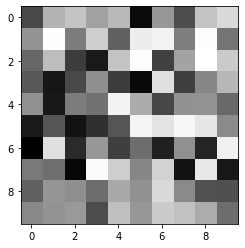

In [ ]:
# Let's create  a vector of 100 elements with a value between 0 and 255
image_bw = np.random.uniform(low=0, high=255, size=100)

# Reshape it into a squared matrix, we have an image of 10x10 pixels
image_bw = image_bw.reshape((10, 10))

# Finally display the generated image
plt.imshow(image_bw, cmap='gray');

### 1.2) Renkli görüntüler :

Her renk ana renklerin doğrusal birleşimidir: Kırmızı, Yeşil, Mavi

Renkli bir görüntü, her ana renk için bir tane olmak üzere üç katmanın üst üste binmesidir.

Dolayısıyla her piksel için üç değerimiz vardır (Kırmızı, Yeşil, Mavi).

<img src="https://miro.medium.com/max/840/1*y0nV4cWk3KbzXSe9dIWL5g.jpeg">

👇 Yine, sadece `numpy` ile oluşturulmuş renkli bir görüntü görmek için aşağıdaki hücreleri çalıştırın.

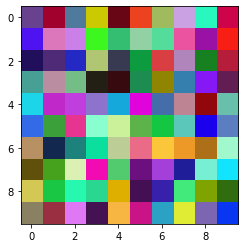

In [ ]:
# Let's create vector of 100*3 elements with a value between 0 and 1
image_c = np.random.uniform(low=0., high=1., size=100*3)

# Reshape it into a squared image of 10x10 pixels with 3 colors
image_c = image_c.reshape((10, 10, 3))

# Finally display the generated image
plt.imshow(image_c);

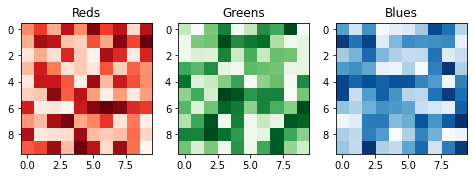

In [ ]:
# To get some intuition, let's plot each color layer
fig, axs = plt.subplots(1, 3, figsize=(8, 6))
colors = {0:'Reds', 1:'Greens', 2:'Blues'}

for i in colors:
    axs[i].imshow(image_c[:, :, i], cmap=colors[i])
    axs[i].set_title(colors[i])

## 2) Makine Öğrenmesi için Görüntüler

### 2.1) Kurulum

`skimage` kütüphanesini kurun, bu bize klasik görüntülere erişim sağlayacak

In [ ]:
! pip install --quiet scikit-image

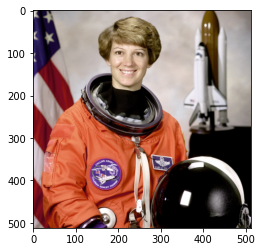

In [ ]:
from skimage import data
img = data.astronaut()
plt.imshow(img);

❓ Bu görüntünün şekli nedir?
`img_shape` değişkenine atayın

In [ ]:
# Get the shape of image
img_shape = img.shape
img_shape

(512, 512, 3)

### 2.2) Renk sayısı

Görüntümüzü sıkıştırma veya genel olarak makine öğrenmesi için hazır hale getirmek için onu **gözlemler** ve **özellikler** olarak temsil etmemiz gerekir.

Her **piksel** bir **gözlemdir**
Her **renk değeri (Kırmızı, Yeşil, Mavi)** bir **özelliktir**

Görüntümüzde **262.144 gözlem** (512 * 512 piksel) ve **3 özellik** (RGB) vardır

❓ Görüntüyü yeniden şekillendirin:
- Mevcut 3 boyutlu `genişlik x yükseklik x 3` şeklinden
- `n_piksel x 3` şeklinde 2 boyutlu bir matrise, burada `n_piksel = genişlik * yükseklik`

Yeniden şekillendirilmiş görüntüyü `X`'e atayın.

In [ ]:
# Reshape
X = img.reshape(img_shape[0] * img_shape[1], img_shape[2])
# Or simpler: X = img.reshape(-1, 3)

Renkli bir görüntü 16 Milyona kadar potansiyel renk içerebilir.

Gerçekten de, her piksel için **3** kanalımız var ve her kanal için **256** olası değerimiz var (0'dan 255'e)
Dolayısıyla renkli bir görüntüde potansiyel maksimum **16.777.216** *($256^3$)* renk vardır

Görüntümüz sadece 262.144 piksel (512 * 512) olduğu için, her piksel üç kanalın değerleriyle tanımlanan tek bir renk içerdiğinden en fazla 262.144 renk kullanır

Hadi sayalım! 🕵️

❓ Bu resimdeki benzersiz renklerin sayısını `color_count` değişkeninde saklayın

In [ ]:
color_count = len(np.unique(X, axis=0))

# pandas alternative
# color_count = len(df_X.drop_duplicates())

Sahip olduklarımızı özetleyelim:
- 262.144 gözlem, her gözlem bir piksel
- Her gözlem için 3 özellik (Kırmızı, Yeşil ve Mavi değerleri)
- Bilinmeyen sayıda küme 😱

**Renk sayısını azaltmak için neler yapabileceğimizi görelim** 🎨

### 🧪 Kodunuzu test edin

In [ ]:
from nbresult import ChallengeResult

result = ChallengeResult('image_analysis',
                         img_shape = img_shape,
                         color_count = color_count)
result.write()
print(result.check())

============================= test session starts ==============================
platform linux -- Python 3.8.12, pytest-6.2.5, py-1.11.0, pluggy-1.0.0 -- /home/vincent/.pyenv/versions/wagon-content/bin/python3
cachedir: .pytest_cache
rootdir: /home/vincent/code/lewagon/data-solutions/05-ML/06-Unsupervised-Learning/01-Image-Compression
plugins: anyio-3.4.0
collecting ... collected 2 items

tests/test_image_analysis.py::TestImageAnalysis::test_color_count PASSED [ 50%]
tests/test_image_analysis.py::TestImageAnalysis::test_img_shape PASSED   [100%]

============================== 2 passed in 0.02s ===============================


💯 You can commit your code:

git add tests/image_analysis.pickle

git commit -m 'Completed image_analysis step'

git push origin master


## 3) K-means ile Sıkıştırma

**113.382** rengi **K** renge indirmek istiyoruz.

Pikseller üzerinde bir `KMeans` algoritması kullanarak her pikseli **K** kümeden birine atayabiliriz!

Her kümenin merkezi, ona ait olan piksellerin ortalama rengi olacaktır.

Daha sonra bu "ortalama küme rengini" kümedeki her piksel için RGB değerleri olarak kullanabiliriz.

💪🧠 Hadi yapalım, amacımız sadece **32** renk kullanmak!

❓ Makine öğrenmesi için hazır görüntünüz `X` üzerinde `n_clusters=32` ile bir K-means eğitin ve `kmeans` değişkenine atayın

In [ ]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=32)
kmeans.fit(X)

KMeans(n_clusters=32)

👉 `kmeans`'inizin `labels_` değerini kontrol edin, ardından `shape` ve `unique değer sayısını` kontrol edin

In [ ]:
kmeans.labels_ # each label represents a cluster

array([26,  5, 17, ...,  0,  0,  0], dtype=int32)

In [ ]:
kmeans.labels_.shape # One cluster per observation

(262144,)

In [ ]:
np.unique(kmeans.labels_).shape # 32 unique clusters

(32,)

☝️ Açıklayalım:

- Her etiket bir kümedir
- Her gözleme bir etiket atanmıştır
- Her küme için bir tane olmak üzere toplam 32 farklı etiket vardır

❓ `KMeans`'inizin `cluster_centers_` değerini, şeklini ve ilk elemanını kontrol edin

In [ ]:
kmeans.cluster_centers_.shape # One center per cluster

(32, 3)

In [ ]:
kmeans.cluster_centers_[0] # Each center is a vector of mean RGB values

array([1.24067657, 0.62364929, 0.63745797])

☝️Her cluster_center bir RGB değerleri vektörüdür, kümenin ortalama rengini temsil eder

❓ Her piksel için karşılık gelen kümenin ortalama rengini saklayan bir `X_compressed` dizisi oluşturun.

<details span="markdown">
    <summary>💡 Yardım</summary>

Bunu sadece `kmeans.cluster_centers_` ve `kmeans.labels_` kullanarak başarabilirsiniz

---

</details>

In [ ]:
%%time
# numpy vectorized way
X_compressed = kmeans.cluster_centers_[kmeans.labels_]
X_compressed

# alternative ways
# Thinking slow
X_compressed = np.array(list(pd.Series(kmeans.labels_).map(lambda x: kmeans.cluster_centers_[x,:])))

# and fast :)
X_compressed = np.apply_along_axis(lambda row: kmeans.cluster_centers_[row,:], axis=0, arr=kmeans.labels_)

CPU times: user 193 ms, sys: 1.08 ms, total: 194 ms
Wall time: 203 ms


RGB değerleri tamsayı olmalıdır.

`X_compressed`'deki renklerimiz `float64` formatındadır.

❓ `X_compressed`'i 0 ile 255 arasında olan işaretsiz 8-bit tamsayı türü olan `uint8`'e dönüştürün.

In [ ]:
X_compressed = X_compressed.astype('uint8')

❓ Kullanılan benzersiz renk sayısının gerçekten 32 olduğunu doğrulayın.

In [ ]:
len(np.unique(X_compressed, axis=0))

32

Neredeyse bitti! 💪

## 4) Sıkıştırılmış görüntüyü çizin

`X_compressed`'in şekli (262144, 3)'tür, bunu görüntü olarak görüntüleyemeyiz.

❓ Sıkıştırılmış görüntünüzü yeniden şekillendirin ve orijinal görüntünüzle yan yana çizin.

<details>
    <summary>💡 İpucu</summary>

Düzleştirilmiş `X_compressed`'inizi bir görüntü için doğru boyutlara yeniden şekillendirmeniz gerekir
Orijinal görüntünüz bu boyutlara sahiptir.

---

</details>

In [ ]:
img_compressed = X_compressed.reshape(*img_shape)

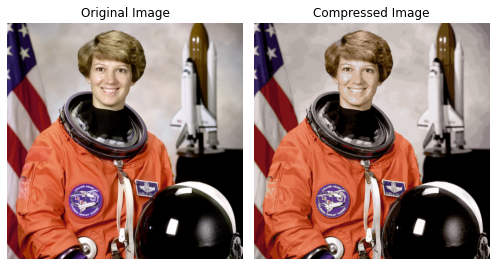

In [ ]:
# Plot the original and the compressed image.
fig, ax = plt.subplots(1, 2, figsize = (7, 7))
ax[0].imshow(img)
ax[0].set_title('Original Image')

ax[1].imshow(img_compressed)
ax[1].set_title('Compressed Image')

# Remove
for ax in fig.axes:
    ax.axis('off')

# Nice padding adjustments
plt.tight_layout()

Aferin! 💪

Bazı renkler kayboldu, ancak orijinal görüntüyü kolayca tanıyabilirsiniz.

🏁 **Notebook'unuzu push etmeyi unutmayın.**

Günün meydan okumalarıyla devam edin ve zamanınız varsa buraya geri dönün 😉

## 5 - İsteğe bağlı) Dirsek yöntemini kullanın

En az renk bilgisini kaybeden optimal sıkıştırmayı bulmak için Dirsek yöntemini kullanmayı deneyebilirsiniz.

Örneğin [5, 10, 20, 30, 50, 70, 100] listesindeki `n_clusters` için `inertia`yı çizmeyi deneyin

⚠️ Uzun eğitim, birkaç dakika bekleyebilirsiniz

In [ ]:
# Apply the elbow method to find the optimal number of clusters.
wcss = []
for i in [5, 10, 20, 30, 50, 70, 100]:
    print('working with ' + str(i) + ' clusters...', flush=True)
    kmeans = KMeans(n_clusters = i, max_iter=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

working with 5 clusters...
working with 10 clusters...
working with 20 clusters...
working with 30 clusters...
working with 50 clusters...
working with 70 clusters...
working with 100 clusters...


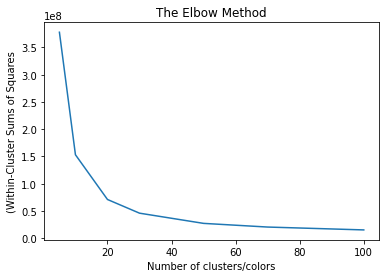

In [ ]:
plt.plot([5, 10, 20, 30, 50, 70, 100], wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters/colors')
plt.ylabel('(Within-Cluster Sums of Squares')
plt.show()

❓ Farklı küme sayıları kullanarak sıkıştırılmış görüntünüzü görselleştirmek için aşağıdaki hücreyi çalıştırın
⚠️ Bu uzun bir eğitimdir, birkaç dakika bekleyeceksiniz

working with 1 clusters...
------------------------------------------------------------------------------------------------------------------------
If we compress our 113382 unique colors into 1 clusters...
The Kmeans inertia is equal to 4891993276.00374


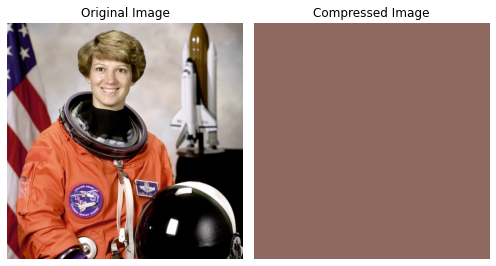

working with 2 clusters...
------------------------------------------------------------------------------------------------------------------------
If we compress our 113382 unique colors into 2 clusters...
The Kmeans inertia is equal to 1509779950.9238002


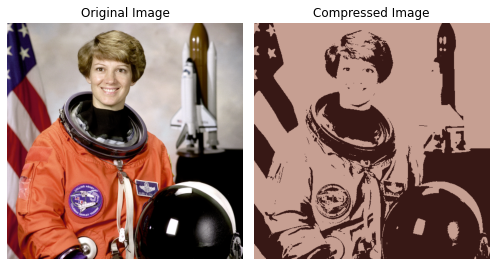

working with 5 clusters...
------------------------------------------------------------------------------------------------------------------------
If we compress our 113382 unique colors into 5 clusters...
The Kmeans inertia is equal to 377716709.5077906


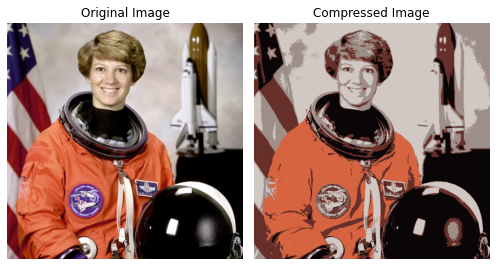

working with 10 clusters...
------------------------------------------------------------------------------------------------------------------------
If we compress our 113382 unique colors into 10 clusters...
The Kmeans inertia is equal to 152886403.88606232


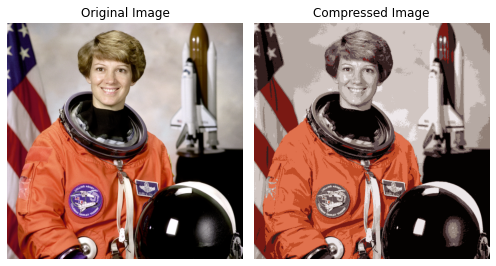

working with 20 clusters...
------------------------------------------------------------------------------------------------------------------------
If we compress our 113382 unique colors into 20 clusters...
The Kmeans inertia is equal to 70776420.63350955


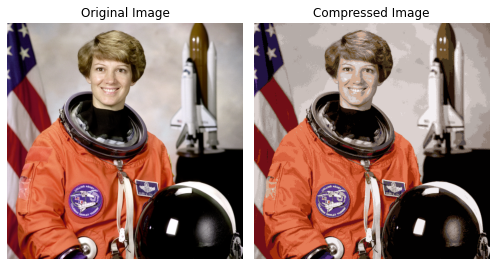

working with 30 clusters...
------------------------------------------------------------------------------------------------------------------------
If we compress our 113382 unique colors into 30 clusters...
The Kmeans inertia is equal to 45587800.849129215


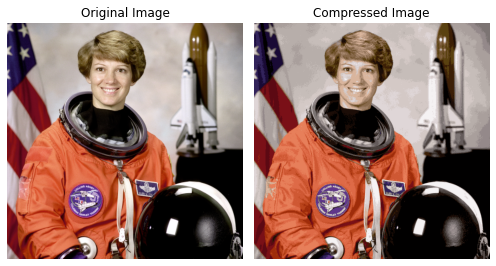

working with 50 clusters...
------------------------------------------------------------------------------------------------------------------------
If we compress our 113382 unique colors into 50 clusters...
The Kmeans inertia is equal to 27231845.059462696


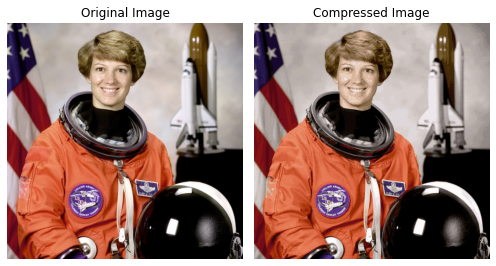

working with 70 clusters...
------------------------------------------------------------------------------------------------------------------------
If we compress our 113382 unique colors into 70 clusters...
The Kmeans inertia is equal to 20566563.451995365


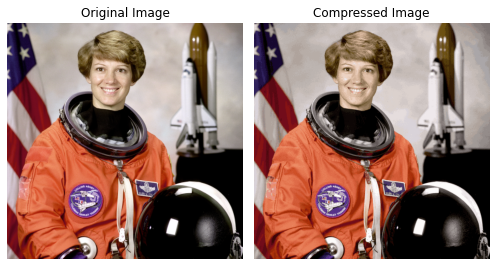

working with 100 clusters...
------------------------------------------------------------------------------------------------------------------------
If we compress our 113382 unique colors into 100 clusters...
The Kmeans inertia is equal to 15198751.602875471


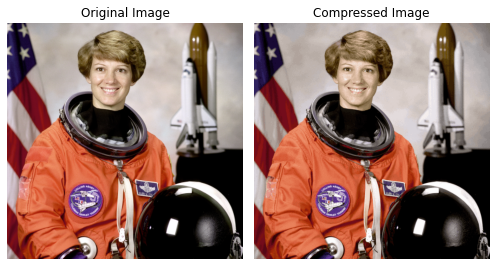

In [ ]:
wcss = []
compressed_astronaut = []
for i in [1, 2, 5, 10, 20, 30, 50, 70, 100]:
    print('working with ' + str(i) + ' clusters...', flush=True)
    kmeans = KMeans(n_clusters = i, max_iter=10)
    kmeans.fit(X)
    # compute inertia
    wcss.append(kmeans.inertia_)
    # compute compressed astronaut
    labels = kmeans.labels_
    centers = kmeans.cluster_centers_
    X_compressed = centers[labels]
    X_compressed = X_compressed.astype('uint8')
    img_compressed = X_compressed.reshape(img_shape[0], img_shape[1], img_shape[2])
    compressed_astronaut.append(img_compressed)
    # printing
    print("-"*120)
    print(f"If we compress our 113382 unique colors into {i} clusters...")
    print(f"The Kmeans inertia is equal to {kmeans.inertia_}")
    fig, ax = plt.subplots(1, 2, figsize = (7, 7))
    ax[0].imshow(img)
    ax[0].set_title('Original Image')
    ax[1].imshow(img_compressed)
    ax[1].set_title('Compressed Image')
    for ax in fig.axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()